In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
prosody_df = pd.read_csv('features/prosody_labels.csv')
prosody_df.head()

,filepath,label
0,features\NORMAL_CALLS\prosody_normal_10_00000.npy,0
1,features\NORMAL_CALLS\prosody_normal_10_00001.npy,0
2,features\NORMAL_CALLS\prosody_normal_10_00002.npy,0
3,features\NORMAL_CALLS\prosody_normal_10_00003.npy,0
4,features\NORMAL_CALLS\prosody_normal_10_00004.npy,0


In [3]:
prosody_df.label.value_counts(normalize=True)

label
1    0.646192
0    0.353808
Name: proportion, dtype: float64

In [4]:
X = []
y = []
for _, row in prosody_df.iterrows():
    feature = np.load(row["filepath"])
    X.append(feature)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

In [5]:
X.shape, y.shape

((407, 12), (407,))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((325, 12), (82, 12), (325,), (82,))

In [7]:
model = RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, n_estimators=300, random_state=42)

In [8]:
y_pred = model.predict(X_test)

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.45      0.55        29
           1       0.75      0.91      0.82        53

    accuracy                           0.74        82
   macro avg       0.74      0.68      0.69        82
weighted avg       0.74      0.74      0.73        82



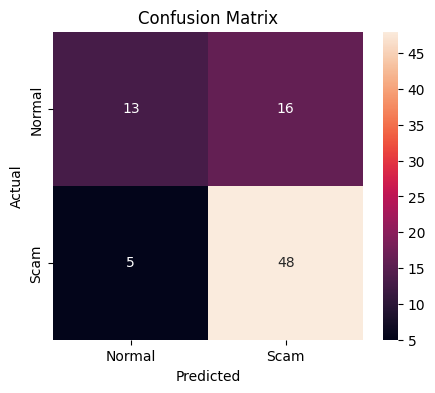

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal","Scam"],
            yticklabels=["Normal","Scam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
print("Training Accuracy: ", model.score(X_train, y_train))
print("Testing Accuracy: ", model.score(X_test, y_test))

Training Accuracy:  0.8369230769230769
Testing Accuracy:  0.7439024390243902


In [12]:
model2 = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.007, random_state=42)
model2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.007, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [13]:
y_pred = model2.predict(X_test)

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.55      0.63        29
           1       0.78      0.89      0.83        53

    accuracy                           0.77        82
   macro avg       0.76      0.72      0.73        82
weighted avg       0.76      0.77      0.76        82



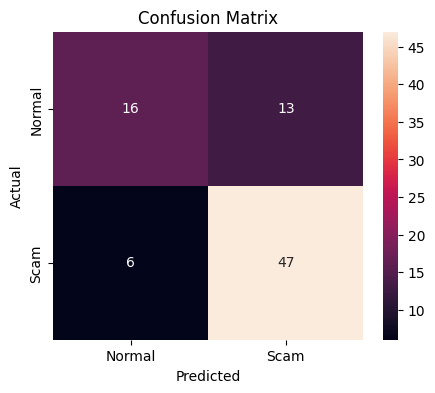

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal","Scam"],
            yticklabels=["Normal","Scam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
print("Training Accuracy: ", model2.score(X_train, y_train))
print("Testing Accuracy: ", model2.score(X_test, y_test))

Training Accuracy:  0.9446153846153846
Testing Accuracy:  0.7682926829268293


In [17]:
model3 = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', solver='adam', alpha=0.003, batch_size=16, learning_rate_init=0.001, max_iter=500, random_state=42)
model3.fit(X_train, y_train)

MLPClassifier(alpha=0.003, batch_size=16, hidden_layer_sizes=(32, 16),
              max_iter=500, random_state=42)

In [18]:
y_pred = model3.predict(X_test)

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.41      0.49        29
           1       0.73      0.85      0.78        53

    accuracy                           0.70        82
   macro avg       0.66      0.63      0.64        82
weighted avg       0.68      0.70      0.68        82



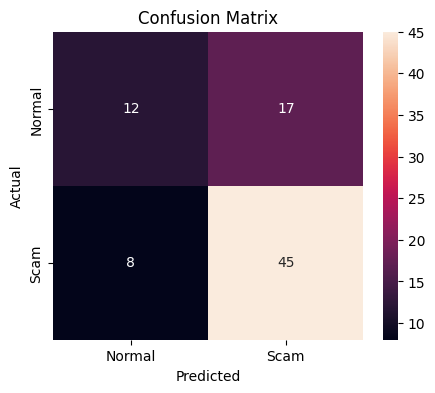

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal","Scam"],
            yticklabels=["Normal","Scam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
print("Training Accuracy: ", model3.score(X_train, y_train))
print("Testing Accuracy: ", model3.score(X_test, y_test))

Training Accuracy:  0.7753846153846153
Testing Accuracy:  0.6951219512195121


In [22]:
import joblib
joblib.dump(model2, 'models/best_prosody_xgb_model.pkl')

['models/best_prosody_xgb_model.pkl']

In [23]:
xgb = joblib.load('models/best_prosody_xgb_model.pkl')
path = r'features\NORMAL_CALLS\prosody_normal_21_00002.npy'

feature = np.load(path)

feature.shape

(12,)

In [24]:
xgb.predict(feature.reshape(1, -1))

array([0])